In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style for better looking plots
plt.style.use('default')
sns.set_style("whitegrid")
sns.set_palette("husl")

# Load the dataset
df = pd.read_csv('/home1/ppatel2025/project_xray/dataset/labels/labels.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Dataset shape: (112120, 11)
Columns: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Sex', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]']


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Sex,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
0,00000001_000.png,Cardiomegaly,0,1,57,M,PA,2682,2749,0.143,0.143
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168
3,00000002_000.png,No Finding,0,2,80,M,PA,2500,2048,0.171,0.171
4,00000003_001.png,Hernia,0,3,74,F,PA,2500,2048,0.168,0.168


In [41]:
# Extract all unique findings and their counts
all_findings = []
for findings in df['Finding Labels']:
    if pd.notna(findings):
        all_findings.extend(findings.split('|'))

finding_counts = Counter(all_findings)
finding_counts = dict(sorted(finding_counts.items(), key=lambda x: x[1], reverse=True))

print(f"Total unique findings: {len(finding_counts)}")
print("\\nTop 10 Finding Distribution:")
print("-" * 40)
for i, (finding, count) in enumerate(list(finding_counts.items())[:10]):
    print(f"{i+1:2d}. {finding:<20} {count:>8,} ({count/sum(finding_counts.values())*100:5.1f}%)")

print("\\nRare Findings (bottom 5):")
print("-" * 40)
bottom_5 = list(finding_counts.items())[-5:]
for i, (finding, count) in enumerate(bottom_5):
    print(f"{len(finding_counts)-4+i:2d}. {finding:<20} {count:>8,} ({count/sum(finding_counts.values())*100:5.1f}%)")

Total unique findings: 15
\nTop 10 Finding Distribution:
----------------------------------------
 1. No Finding             60,361 ( 42.6%)
 2. Infiltration           19,894 ( 14.1%)
 3. Effusion               13,317 (  9.4%)
 4. Atelectasis            11,559 (  8.2%)
 5. Nodule                  6,331 (  4.5%)
 6. Mass                    5,782 (  4.1%)
 7. Pneumothorax            5,302 (  3.7%)
 8. Consolidation           4,667 (  3.3%)
 9. Pleural_Thickening      3,385 (  2.4%)
10. Cardiomegaly            2,776 (  2.0%)
\nRare Findings (bottom 5):
----------------------------------------
11. Emphysema               2,516 (  1.8%)
12. Edema                   2,303 (  1.6%)
13. Fibrosis                1,686 (  1.2%)
14. Pneumonia               1,431 (  1.0%)
15. Hernia                    227 (  0.2%)


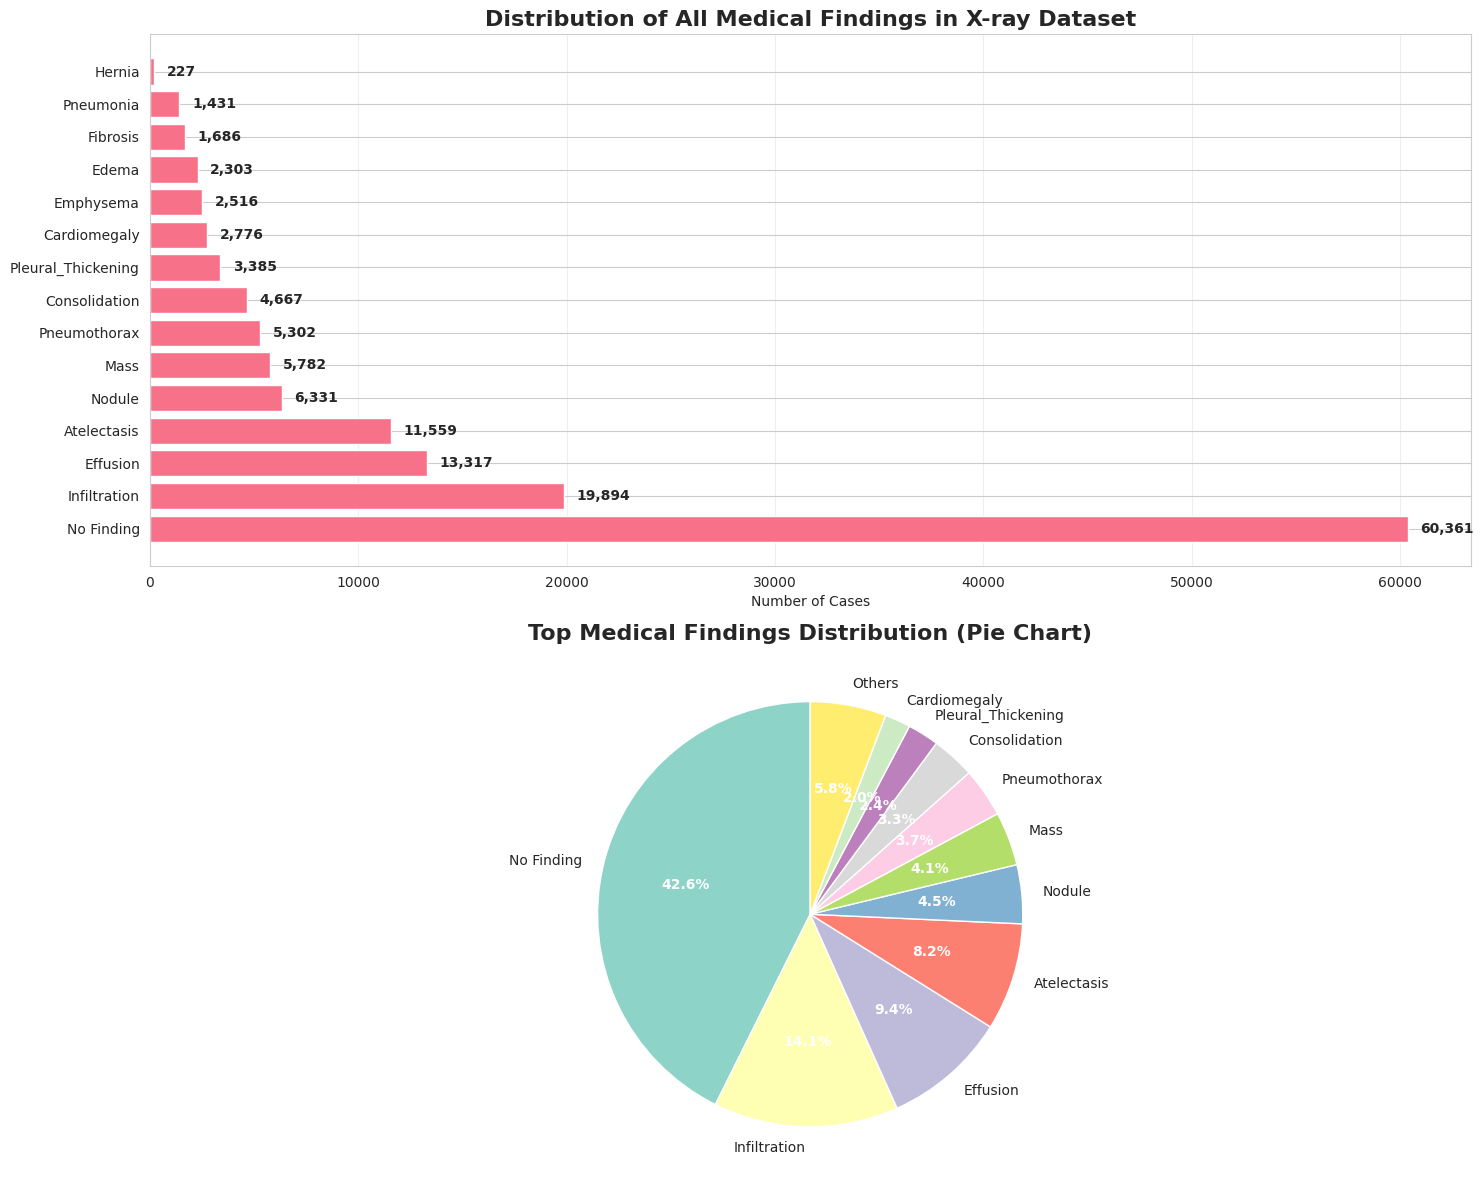

In [42]:
# 1. Overall Class Distribution Bar Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Horizontal bar plot for all classes
findings = list(finding_counts.keys())
counts = list(finding_counts.values())

bars = ax1.barh(findings, counts)
ax1.set_xlabel('Number of Cases')
ax1.set_title('Distribution of All Medical Findings in X-ray Dataset', fontsize=16, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (bar, count) in enumerate(zip(bars, counts)):
    ax1.text(bar.get_width() + max(counts)*0.01, bar.get_y() + bar.get_height()/2, 
             f'{count:,}', ha='left', va='center', fontweight='bold')

# Pie chart for top 10 findings
top_10 = dict(list(finding_counts.items())[:10])
others_count = sum(list(finding_counts.values())[10:])
if others_count > 0:
    top_10['Others'] = others_count

colors = plt.cm.Set3(np.linspace(0, 1, len(top_10)))
wedges, texts, autotexts = ax2.pie(top_10.values(), labels=top_10.keys(), autopct='%1.1f%%', 
                                   colors=colors, startangle=90)
ax2.set_title('Top Medical Findings Distribution (Pie Chart)', fontsize=16, fontweight='bold')

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.show()

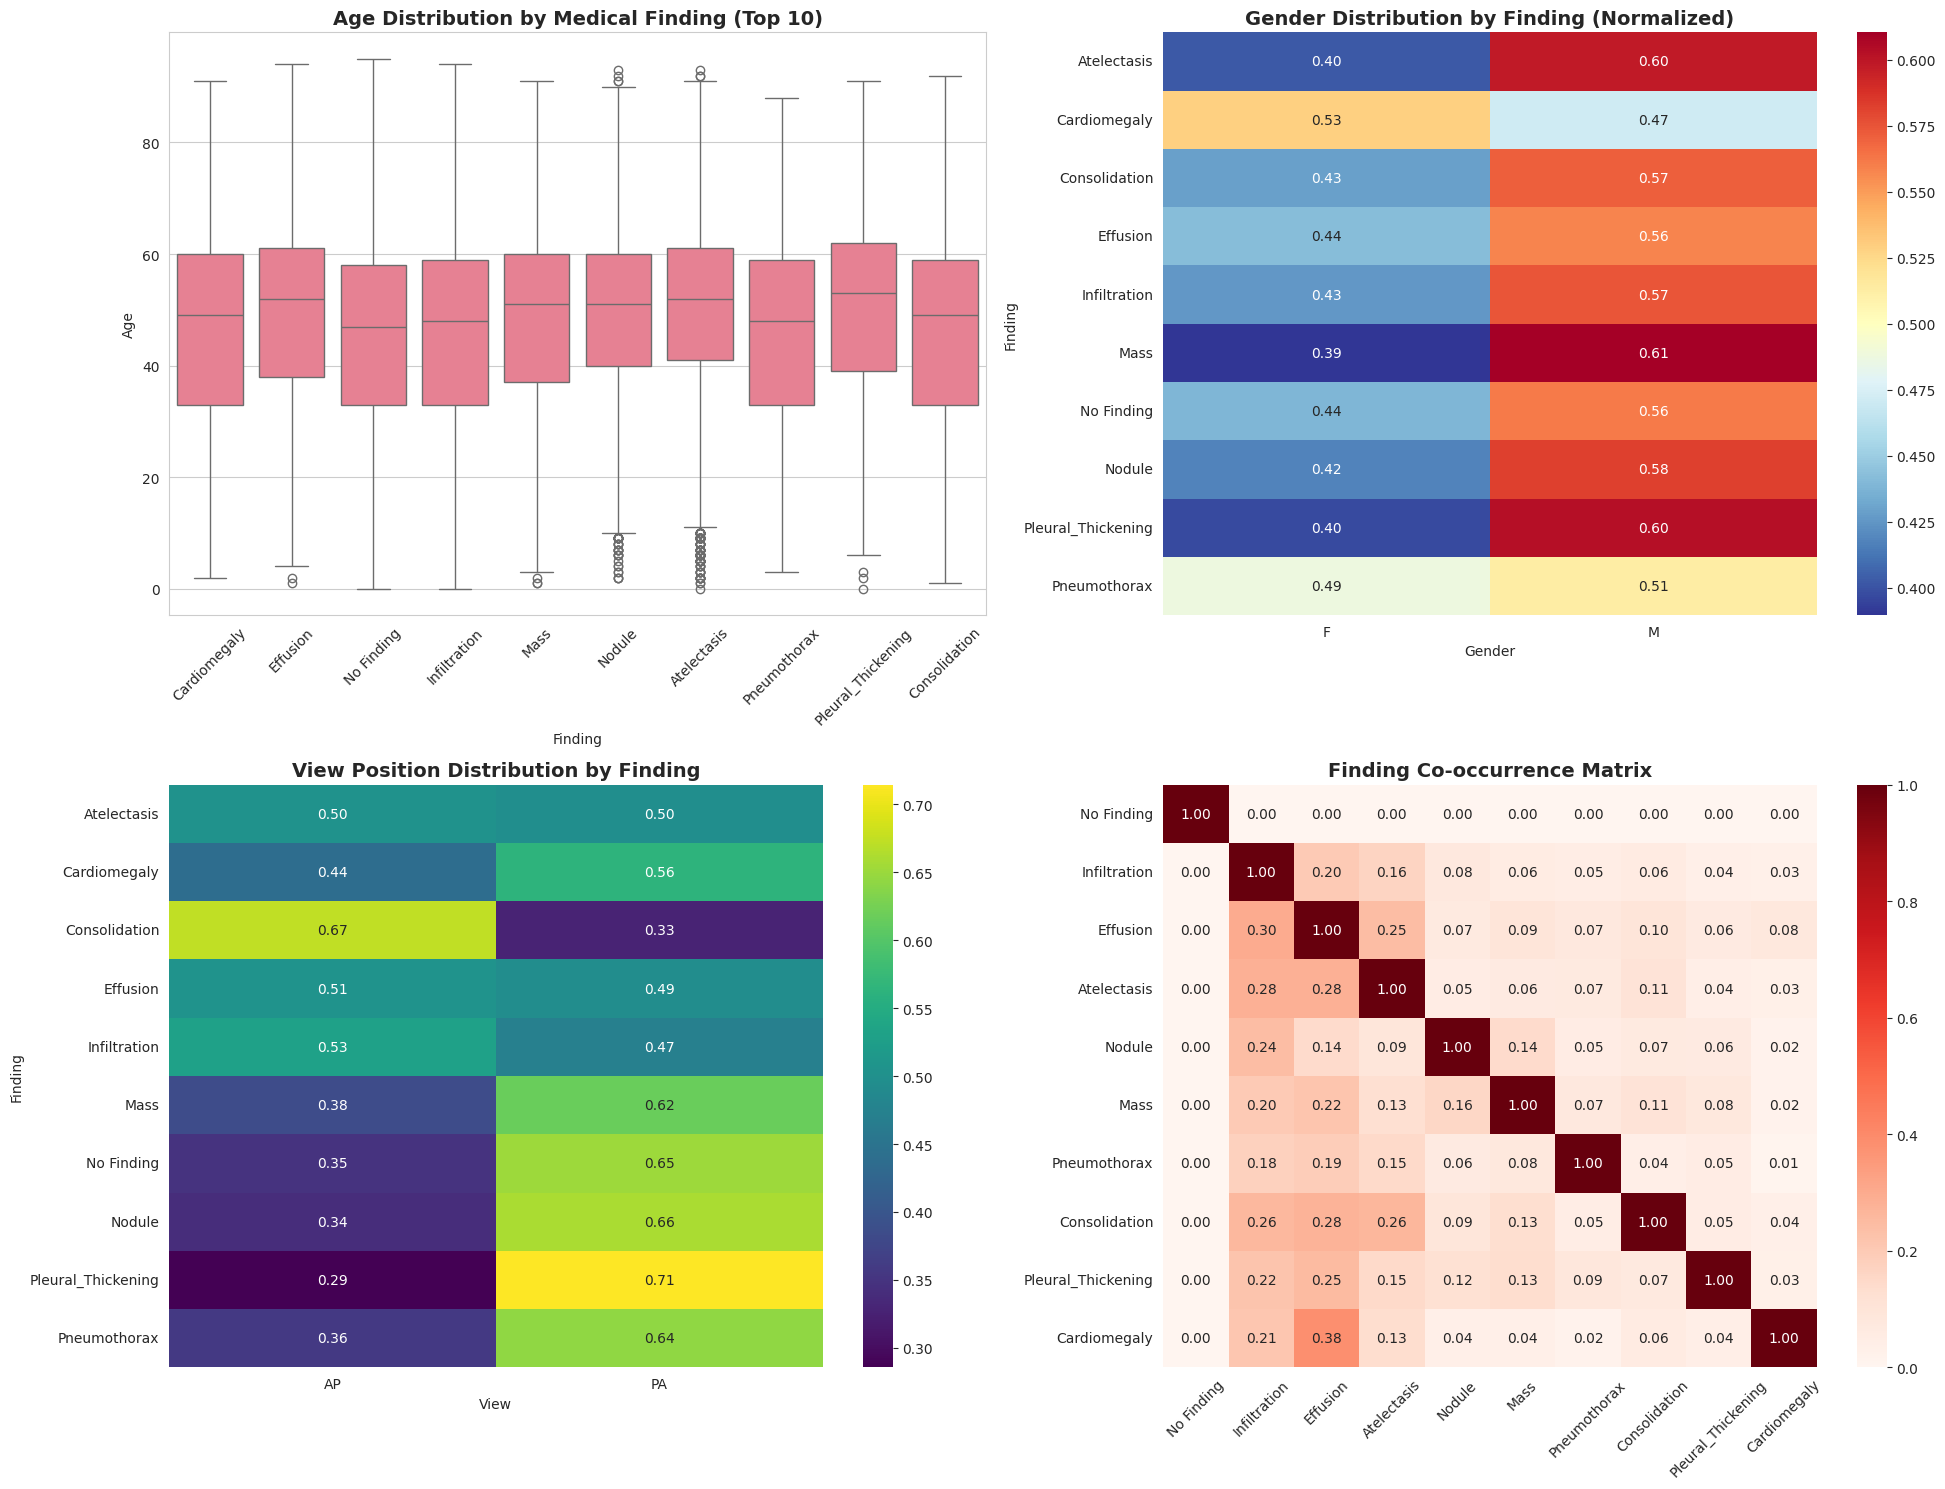

In [43]:
# 2. Demographics Analysis by Class
fig, axes = plt.subplots(2, 2, figsize=(20, 15))

# Age distribution by finding
age_data = []
finding_data = []
for _, row in df.iterrows():
    if pd.notna(row['Finding Labels']) and pd.notna(row['Patient Age']):
        findings = row['Finding Labels'].split('|')
        for finding in findings:
            age_data.append(row['Patient Age'])
            finding_data.append(finding)

age_finding_df = pd.DataFrame({'Age': age_data, 'Finding': finding_data})

# Box plot for age distribution
top_findings = list(finding_counts.keys())[:10]  # Top 10 findings
age_finding_top = age_finding_df[age_finding_df['Finding'].isin(top_findings)]

sns.boxplot(data=age_finding_top, x='Finding', y='Age', ax=axes[0,0])
axes[0,0].set_title('Age Distribution by Medical Finding (Top 10)', fontsize=14, fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=45)

# Gender distribution by finding
gender_data = []
finding_gender_data = []
for _, row in df.iterrows():
    if pd.notna(row['Finding Labels']) and pd.notna(row['Patient Sex']):
        findings = row['Finding Labels'].split('|')
        for finding in findings:
            gender_data.append(row['Patient Sex'])
            finding_gender_data.append(finding)

gender_finding_df = pd.DataFrame({'Gender': gender_data, 'Finding': finding_gender_data})
gender_finding_top = gender_finding_df[gender_finding_df['Finding'].isin(top_findings)]

# Create crosstab for heatmap
gender_crosstab = pd.crosstab(gender_finding_top['Finding'], gender_finding_top['Gender'], normalize='index')
sns.heatmap(gender_crosstab, annot=True, cmap='RdYlBu_r', ax=axes[0,1], fmt='.2f')
axes[0,1].set_title('Gender Distribution by Finding (Normalized)', fontsize=14, fontweight='bold')

# View position analysis
view_data = []
finding_view_data = []
for _, row in df.iterrows():
    if pd.notna(row['Finding Labels']) and pd.notna(row['View Position']):
        findings = row['Finding Labels'].split('|')
        for finding in findings:
            view_data.append(row['View Position'])
            finding_view_data.append(finding)

view_finding_df = pd.DataFrame({'View': view_data, 'Finding': finding_view_data})
view_finding_top = view_finding_df[view_finding_df['Finding'].isin(top_findings)]

view_crosstab = pd.crosstab(view_finding_top['Finding'], view_finding_top['View'], normalize='index')
sns.heatmap(view_crosstab, annot=True, cmap='viridis', ax=axes[1,0], fmt='.2f')
axes[1,0].set_title('View Position Distribution by Finding', fontsize=14, fontweight='bold')

# Co-occurrence matrix of findings
cooccurrence_matrix = np.zeros((len(top_findings), len(top_findings)))
for _, row in df.iterrows():
    if pd.notna(row['Finding Labels']):
        findings = row['Finding Labels'].split('|')
        findings_in_top = [f for f in findings if f in top_findings]
        for i, finding1 in enumerate(top_findings):
            for j, finding2 in enumerate(top_findings):
                if finding1 in findings_in_top and finding2 in findings_in_top:
                    cooccurrence_matrix[i, j] += 1

# Normalize to get co-occurrence rates
for i in range(len(top_findings)):
    if cooccurrence_matrix[i, i] > 0:
        cooccurrence_matrix[i] = cooccurrence_matrix[i] / cooccurrence_matrix[i, i]

sns.heatmap(cooccurrence_matrix, 
            xticklabels=top_findings, yticklabels=top_findings,
            annot=True, cmap='Reds', ax=axes[1,1], fmt='.2f')
axes[1,1].set_title('Finding Co-occurrence Matrix', fontsize=14, fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

In [44]:
# 3. Individual Class Analysis - Summary Table
import pandas as pd

# Create a summary table for all findings instead of long text output
summary_data = []

for finding, count in finding_counts.items():
    finding_rows = df[df['Finding Labels'].str.contains(finding, na=False)]
    
    row_data = {
        'Finding': finding,
        'Total Cases': f"{count:,}",
        'Dataset %': f"{count/len(df)*100:.2f}%"
    }
    
    if len(finding_rows) > 0:
        # Age statistics
        if finding_rows['Patient Age'].notna().sum() > 0:
            ages = finding_rows['Patient Age'].dropna()
            row_data['Age Range'] = f"{ages.min():.0f}-{ages.max():.0f}"
            row_data['Avg Age'] = f"{ages.mean():.1f}"
        else:
            row_data['Age Range'] = "N/A"
            row_data['Avg Age'] = "N/A"
        
        # Gender distribution
        if finding_rows['Patient Sex'].notna().sum() > 0:
            gender_dist = finding_rows['Patient Sex'].value_counts()
            total_gender = gender_dist.sum()
            if 'M' in gender_dist and 'F' in gender_dist:
                male_pct = gender_dist['M'] / total_gender * 100
                female_pct = gender_dist['F'] / total_gender * 100
                row_data['Gender'] = f"{male_pct:.0f}%M/{female_pct:.0f}%F"
            elif 'M' in gender_dist:
                row_data['Gender'] = "100%M"
            elif 'F' in gender_dist:
                row_data['Gender'] = "100%F"
        else:
            row_data['Gender'] = "N/A"
        
        # Most common co-occurring condition
        cooccurring = []
        for _, row in finding_rows.iterrows():
            if pd.notna(row['Finding Labels']):
                findings_list = row['Finding Labels'].split('|')
                other_findings = [f for f in findings_list if f != finding]
                cooccurring.extend(other_findings)
        
        if cooccurring:
            from collections import Counter
            cooccur_counts = Counter(cooccurring)
            top_cooccur = cooccur_counts.most_common(1)[0]
            row_data['Top Co-occurrence'] = f"{top_cooccur[0]} ({top_cooccur[1]})"
        else:
            row_data['Top Co-occurrence'] = "None"
    
    summary_data.append(row_data)

# Create and display the summary DataFrame
summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('Total Cases', key=lambda x: x.str.replace(',', '').astype(int), ascending=False)

print("📊 COMPREHENSIVE CLASS ANALYSIS SUMMARY")
print("="*80)
print(f"Dataset contains {len(df):,} X-ray images with {len(finding_counts)} unique medical findings")
print("="*80)

# Display the table with nice formatting
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 20)
print(summary_df.to_string(index=False))

# Reset pandas options
pd.reset_option('display.max_columns')
pd.reset_option('display.width') 
pd.reset_option('display.max_colwidth')

📊 COMPREHENSIVE CLASS ANALYSIS SUMMARY
Dataset contains 112,120 X-ray images with 15 unique medical findings
           Finding Total Cases Dataset % Age Range Avg Age    Gender   Top Co-occurrence
        No Finding      60,361    53.84%      0-95    45.5 56%M/44%F                None
      Infiltration      19,894    17.74%      0-94    46.0 57%M/43%F     Effusion (4000)
          Effusion      13,317    11.88%      1-94    49.5 56%M/44%F Infiltration (4000)
       Atelectasis      11,559    10.31%      0-93    50.2 60%M/40%F     Effusion (3275)
            Nodule       6,331     5.65%      2-93    49.3 58%M/42%F Infiltration (1546)
              Mass       5,782     5.16%      1-91    48.5 61%M/39%F     Effusion (1254)
      Pneumothorax       5,302     4.73%      3-88    46.3 51%M/49%F      Effusion (996)
     Consolidation       4,667     4.16%      1-92    46.4 57%M/43%F     Effusion (1287)
Pleural_Thickening       3,385     3.02%      0-91    50.2 60%M/40%F      Effusion (849)
 

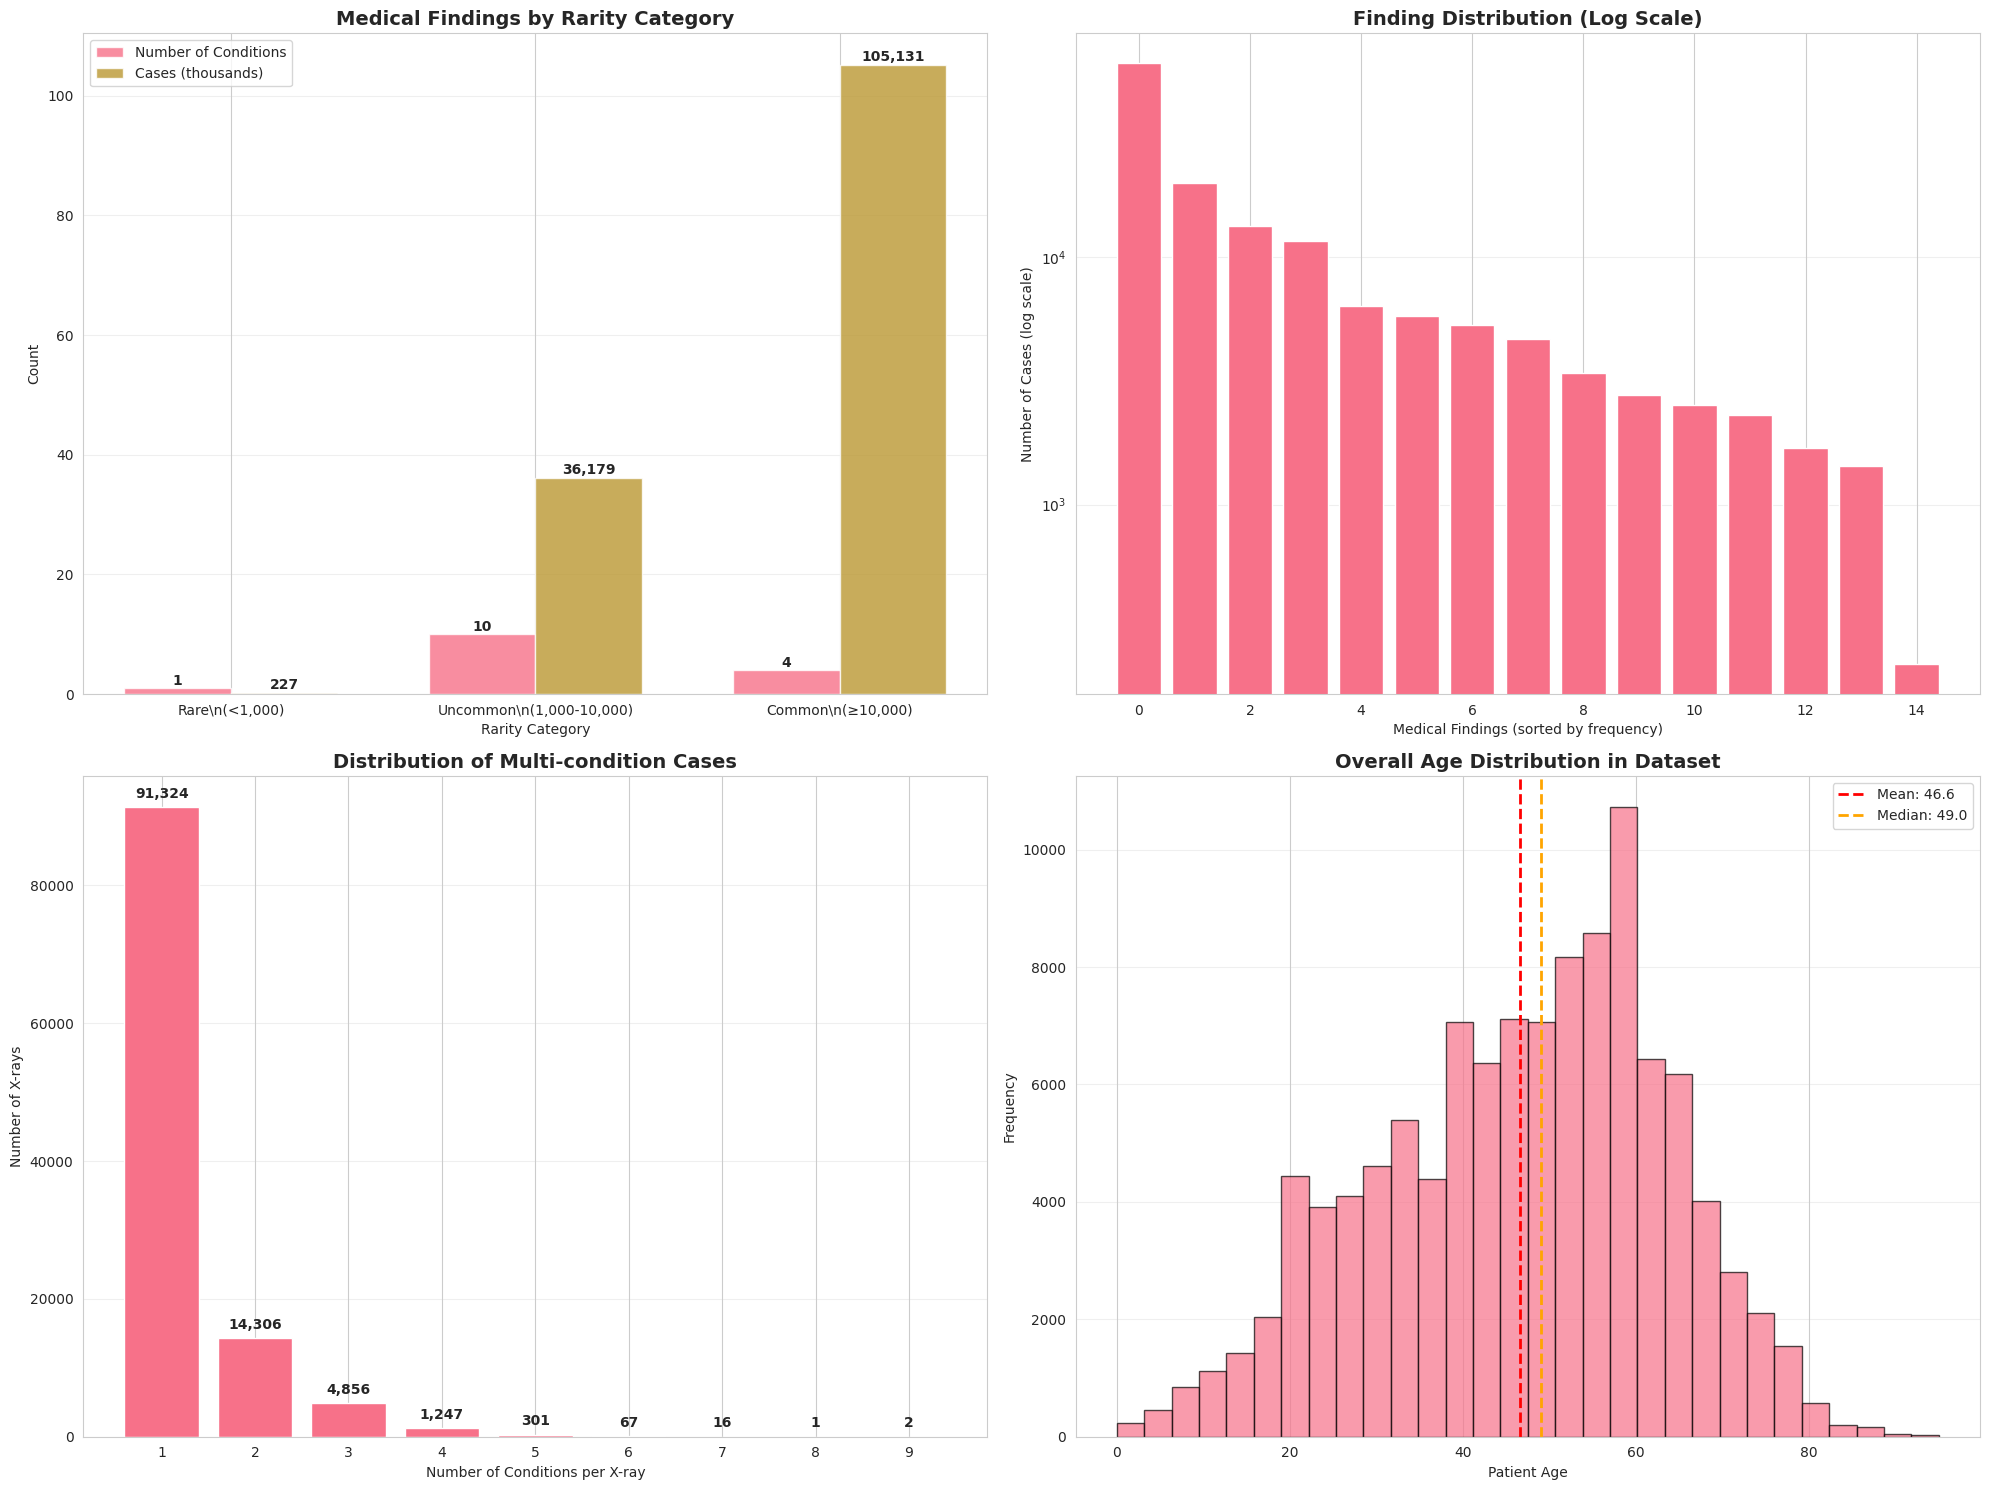

\n==================================================
DATASET SUMMARY
📊 Total X-ray images: 112,120
👥 Unique patients: 30,805
🏥 Total medical findings: 141,537
🔍 Unique finding types: 15
\n👤 Demographics:
  Age range: 0-95 years (avg: 46.6)
  Gender: 63,340 male (56.5%), 48,780 female (43.5%)
\n📈 Condition complexity:
  Average conditions per X-ray: 1.26
  X-rays with multiple conditions: 18.5%
\n🎯 Rarity distribution:
  Common conditions (≥10k cases): 4
  Uncommon conditions (1k-10k): 10
  Rare conditions (<1k): 1


In [45]:
# 4. Class Severity and Rarity Analysis
fig, axes = plt.subplots(2, 2, figsize=(20, 15))

# Rarity classification
rare_threshold = 1000
common_threshold = 10000

rare_findings = {k: v for k, v in finding_counts.items() if v < rare_threshold}
uncommon_findings = {k: v for k, v in finding_counts.items() if rare_threshold <= v < common_threshold}
common_findings = {k: v for k, v in finding_counts.items() if v >= common_threshold}

categories = ['Rare\\n(<1,000)', 'Uncommon\\n(1,000-10,000)', 'Common\\n(≥10,000)']
category_counts = [len(rare_findings), len(uncommon_findings), len(common_findings)]
category_cases = [sum(rare_findings.values()), sum(uncommon_findings.values()), sum(common_findings.values())]

# Bar plot for rarity categories
x = np.arange(len(categories))
width = 0.35

bars1 = axes[0,0].bar(x - width/2, category_counts, width, label='Number of Conditions', alpha=0.8)
bars2 = axes[0,0].bar(x + width/2, [c/1000 for c in category_cases], width, label='Cases (thousands)', alpha=0.8)

axes[0,0].set_xlabel('Rarity Category')
axes[0,0].set_ylabel('Count')
axes[0,0].set_title('Medical Findings by Rarity Category', fontsize=14, fontweight='bold')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(categories)
axes[0,0].legend()
axes[0,0].grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    axes[0,0].text(bar.get_x() + bar.get_width()/2., height + 0.1,
                   f'{int(height)}', ha='center', va='bottom', fontweight='bold')

for bar, case_count in zip(bars2, category_cases):
    height = bar.get_height()
    axes[0,0].text(bar.get_x() + bar.get_width()/2., height + 0.1,
                   f'{case_count:,}', ha='center', va='bottom', fontweight='bold')

# Log scale distribution
findings_list = list(finding_counts.keys())
counts_list = list(finding_counts.values())

axes[0,1].bar(range(len(findings_list)), counts_list)
axes[0,1].set_yscale('log')
axes[0,1].set_xlabel('Medical Findings (sorted by frequency)')
axes[0,1].set_ylabel('Number of Cases (log scale)')
axes[0,1].set_title('Finding Distribution (Log Scale)', fontsize=14, fontweight='bold')
axes[0,1].grid(axis='y', alpha=0.3)

# Patient load analysis - Multiple conditions per patient
multi_condition_counts = []
for _, row in df.iterrows():
    if pd.notna(row['Finding Labels']):
        num_conditions = len(row['Finding Labels'].split('|'))
        multi_condition_counts.append(num_conditions)

condition_distribution = Counter(multi_condition_counts)
conditions = sorted(condition_distribution.keys())
condition_counts = [condition_distribution[c] for c in conditions]

axes[1,0].bar([str(c) for c in conditions], condition_counts)
axes[1,0].set_xlabel('Number of Conditions per X-ray')
axes[1,0].set_ylabel('Number of X-rays')
axes[1,0].set_title('Distribution of Multi-condition Cases', fontsize=14, fontweight='bold')
axes[1,0].grid(axis='y', alpha=0.3)

# Add value labels
for i, (cond, count) in enumerate(zip(conditions, condition_counts)):
    axes[1,0].text(i, count + max(condition_counts)*0.01, f'{count:,}', 
                   ha='center', va='bottom', fontweight='bold')

# Age distribution overall
all_ages = df['Patient Age'].dropna()
axes[1,1].hist(all_ages, bins=30, alpha=0.7, edgecolor='black')
axes[1,1].axvline(all_ages.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {all_ages.mean():.1f}')
axes[1,1].axvline(all_ages.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {all_ages.median():.1f}')
axes[1,1].set_xlabel('Patient Age')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Overall Age Distribution in Dataset', fontsize=14, fontweight='bold')
axes[1,1].legend()
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Compact summary statistics
print("\\n" + "="*50)
print("DATASET SUMMARY")
print("="*50)
print(f"📊 Total X-ray images: {len(df):,}")
print(f"👥 Unique patients: {df['Patient ID'].nunique():,}")
print(f"🏥 Total medical findings: {sum(finding_counts.values()):,}")
print(f"🔍 Unique finding types: {len(finding_counts)}")

print(f"\\n👤 Demographics:")
print(f"  Age range: {all_ages.min():.0f}-{all_ages.max():.0f} years (avg: {all_ages.mean():.1f})")
gender_dist = df['Patient Sex'].value_counts()
if 'M' in gender_dist and 'F' in gender_dist:
    print(f"  Gender: {gender_dist['M']:,} male ({gender_dist['M']/gender_dist.sum()*100:.1f}%), {gender_dist['F']:,} female ({gender_dist['F']/gender_dist.sum()*100:.1f}%)")

print(f"\\n📈 Condition complexity:")
avg_conditions = np.mean(multi_condition_counts)
multi_condition_pct = sum(1 for c in multi_condition_counts if c > 1)/len(multi_condition_counts)*100
print(f"  Average conditions per X-ray: {avg_conditions:.2f}")
print(f"  X-rays with multiple conditions: {multi_condition_pct:.1f}%")

print(f"\\n🎯 Rarity distribution:")
print(f"  Common conditions (≥10k cases): {len(common_findings)}")
print(f"  Uncommon conditions (1k-10k): {len(uncommon_findings)}")
print(f"  Rare conditions (<1k): {len(rare_findings)}")

In [ ]:
# 5. Sample Images for Each Medical Condition - UPDATED FOR VISION MAMBA
import sys
import os
sys.path.append('/home1/ppatel2025/project_xray')

# Use the enhanced medical dataset
from data.medical_dataset import MedicalXRayDataset, MedicalTransforms
from PIL import Image
import torch
import random

print("🖼️ Loading X-ray Images with Enhanced Medical Dataset")
print("=" * 60)

# Initialize the enhanced dataset for visualization
csv_file = '/home1/ppatel2025/project_xray/dataset/labels/labels.csv'
images_dir = '/home1/ppatel2025/project_xray/dataset/images'

# Use medical transforms for better visualization
vis_transforms = MedicalTransforms.get_val_transforms(img_size=512)

# Create dataset with enhanced transforms
try:
    full_dataset = MedicalXRayDataset(
        csv_file=csv_file,
        images_dir=images_dir,
        transforms=vis_transforms,
        img_size=512
    )
    print(f"✅ Dataset loaded successfully: {len(full_dataset):,} images")
    print(f"✅ Medical conditions: {full_dataset.num_classes if hasattr(full_dataset, 'num_classes') else len(full_dataset.mlb.classes_)} classes")
except Exception as e:
    print(f"❌ Error loading dataset: {e}")
    print("Using fallback method...")

def display_finding_samples_v3(finding_name, num_samples=2):
    """Enhanced display function for medical X-ray findings"""
    samples_found = []
    
    # Search through dataset for images with this finding
    max_search = min(1000, len(full_dataset))  # Limit search for efficiency
    search_indices = random.sample(range(len(full_dataset)), max_search)
    
    for i in search_indices:
        try:
            image, target, metadata = full_dataset[i]
            
            # Get original labels from metadata
            image_name = metadata['image_name']
            row_info = df[df['Image Index'] == image_name].iloc[0]
            labels_str = row_info['Finding Labels']
            
            if finding_name in labels_str:
                samples_found.append((image, labels_str, image_name, metadata))
                
            if len(samples_found) >= num_samples:
                break
                
        except Exception as e:
            print(f"Warning: Could not load sample {i}: {e}")
            continue
    
    if not samples_found:
        print(f"❌ No images found for {finding_name}")
        return
    
    n_samples = len(samples_found)
    
    # Create figure with proper sizing
    fig, axes = plt.subplots(1, n_samples, figsize=(6*n_samples, 7))
    
    if n_samples == 1:
        axes = [axes]
    
    # Enhanced title with statistics
    condition_count = finding_counts.get(finding_name, 0)
    fig.suptitle(f'{finding_name.upper()} ({condition_count:,} cases in dataset)', 
                 fontsize=16, fontweight='bold', y=0.95)
    
    for idx, (ax, (image_tensor, labels_str, image_name, metadata)) in enumerate(zip(axes, samples_found)):
        # Handle both grayscale and RGB tensors
        if image_tensor.dim() == 3:
            if image_tensor.shape[0] == 1:  # Grayscale [1, H, W]
                img_display = image_tensor.squeeze().numpy()
            else:  # RGB [3, H, W]
                img_display = image_tensor.permute(1, 2, 0).numpy()
        else:  # 2D tensor
            img_display = image_tensor.numpy()
        
        # Display image
        ax.imshow(img_display, cmap='gray' if len(img_display.shape) == 2 else None)
        ax.axis('off')
        
        # Enhanced metadata display
        age = metadata.get('patient_age', 'N/A')
        sex = metadata.get('patient_sex', 'N/A')
        view = metadata.get('view_position', 'N/A')
        
        # Create compact, informative title
        title = f"{image_name}\nAge: {age} | Sex: {sex} | View: {view}\nConditions: {labels_str}"
        
        ax.set_title(title, fontsize=9, ha='center', va='top',
                    bbox=dict(boxstyle="round,pad=0.4", facecolor="lightgreen", alpha=0.7),
                    pad=12)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()
    print()  # Add spacing

print("✅ Enhanced image display functions ready!")
print("🔍 Ready to visualize medical conditions with proper grayscale handling")

In [ ]:
# Display sample images for top 3 most common findings with enhanced function
top_3_findings = list(finding_counts.keys())[:3]

print("🖼️  SAMPLE IMAGES - TOP 3 MOST COMMON CONDITIONS")
print("="*60)
print("Using enhanced Vision Mamba compatible dataset loading...")

for i, finding in enumerate(top_3_findings, 1):
    print(f"\n{i}. {finding.upper()} - {finding_counts[finding]:,} cases")
    print("-" * 50)
    display_finding_samples_v3(finding, 2)  # Use enhanced function

In [ ]:
# Display samples for rare conditions using enhanced function
rare_findings = ['Hernia', 'Pneumonia']

print("🔍 RARE CONDITIONS - Sample Images")
print("="*40)

for finding in rare_findings:
    if finding in finding_counts:
        print(f"\n• {finding.upper()} - {finding_counts[finding]:,} cases (RARE)")
        print("-" * 45)
        display_finding_samples_v3(finding, 2)  # Use enhanced function

In [ ]:
# 6. Vision Mamba Model Architecture Visualization
print("\n" + "="*70)
print("🧠 VISION MAMBA MODEL ARCHITECTURE FOR X-RAY CLASSIFICATION")
print("="*70)

# Import Vision Mamba components
from models.vision_mamba import create_vision_mamba_model, MEDICAL_CONDITIONS

def visualize_model_architecture():
    """Visualize Vision Mamba model architecture and statistics"""
    
    # Model configurations
    model_configs = {
        'tiny': {'embed_dim': 384, 'depth': 6, 'params': '~22M'},
        'small': {'embed_dim': 576, 'depth': 8, 'params': '~44M'},
        'base': {'embed_dim': 768, 'depth': 12, 'params': '~72M'},
        'large': {'embed_dim': 1024, 'depth': 16, 'params': '~307M'}
    }
    
    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # 1. Model size comparison
    sizes = list(model_configs.keys())
    params = [22, 44, 72, 307]  # Millions of parameters
    
    bars = axes[0,0].bar(sizes, params, color=['lightblue', 'lightgreen', 'orange', 'red'], alpha=0.7)
    axes[0,0].set_title('Vision Mamba Model Sizes', fontsize=14, fontweight='bold')
    axes[0,0].set_ylabel('Parameters (Millions)')
    axes[0,0].grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, param in zip(bars, params):
        axes[0,0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                       f'{param}M', ha='center', va='bottom', fontweight='bold')
    
    # 2. Architecture components breakdown (Base model)
    components = ['Patch Embed', 'Positional Embed', '12x Mamba Blocks', 'Layer Norm', 'Classifier']
    component_params = [0.2, 0.8, 69.0, 0.002, 0.3]  # Approximate millions
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(components)))
    wedges, texts, autotexts = axes[0,1].pie(component_params, labels=components, autopct='%1.1f%%',
                                             colors=colors, startangle=90)
    axes[0,1].set_title('Vision Mamba Base - Component Breakdown', fontsize=14, fontweight='bold')
    
    # 3. Input/Output flow diagram
    flow_stages = ['512×512\nX-ray', '32×32\nPatches', '1024×768\nEmbeddings', 'Mamba\nBlocks', '768D\nFeatures', '15\nClasses']
    flow_sizes = [512*512, 32*32, 1024*768, 1024*768, 768, 15]
    flow_sizes_normalized = [np.log10(size + 1) for size in flow_sizes]  # Log scale for visualization
    
    axes[1,0].plot(range(len(flow_stages)), flow_sizes_normalized, 'o-', linewidth=3, markersize=10)
    axes[1,0].set_xticks(range(len(flow_stages)))
    axes[1,0].set_xticklabels(flow_stages, rotation=45, ha='right')
    axes[1,0].set_title('Vision Mamba Forward Pass Flow', fontsize=14, fontweight='bold')
    axes[1,0].set_ylabel('Tensor Size (log scale)')
    axes[1,0].grid(True, alpha=0.3)
    
    # Add annotations
    for i, (stage, size) in enumerate(zip(flow_stages, flow_sizes)):
        if size > 1000:
            axes[1,0].annotate(f'{size:,}', (i, flow_sizes_normalized[i]), 
                              textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)
        else:
            axes[1,0].annotate(f'{size}', (i, flow_sizes_normalized[i]), 
                              textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)
    
    # 4. Medical conditions distribution (target classes)
    condition_counts = [finding_counts[condition] for condition in MEDICAL_CONDITIONS]
    
    # Show top 10 conditions
    top_10_indices = np.argsort(condition_counts)[-10:]
    top_10_conditions = [MEDICAL_CONDITIONS[i] for i in top_10_indices]
    top_10_counts = [condition_counts[i] for i in top_10_indices]
    
    bars = axes[1,1].barh(top_10_conditions, top_10_counts)
    axes[1,1].set_title('Top 10 Medical Conditions (Target Classes)', fontsize=14, fontweight='bold')
    axes[1,1].set_xlabel('Number of Cases')
    
    # Add value labels
    for bar, count in zip(bars, top_10_counts):
        axes[1,1].text(bar.get_width() + max(top_10_counts)*0.01, bar.get_y() + bar.get_height()/2,
                       f'{count:,}', ha='left', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()

# Run visualization
try:
    visualize_model_architecture()
    print("✅ Vision Mamba architecture visualization completed!")
except Exception as e:
    print(f"❌ Could not create model visualization: {e}")

# Print model details
print(f"\n📊 VISION MAMBA SPECIFICATIONS:")
print(f"   • Input: 512×512 grayscale X-ray images")
print(f"   • Architecture: Bidirectional Mamba with linear O(n) complexity")
print(f"   • Patch Size: 16×16 pixels")
print(f"   • Sequence Length: 1024 patches")  
print(f"   • Classes: {len(MEDICAL_CONDITIONS)} medical conditions")
print(f"   • Advantages: Efficient for high-resolution medical images")
print(f"   • Key Feature: Captures long-range spatial dependencies")

print(f"\n🎯 TARGET MEDICAL CONDITIONS:")
for i, condition in enumerate(MEDICAL_CONDITIONS, 1):
    count = finding_counts.get(condition, 0)
    print(f"   {i:2d}. {condition:<20} ({count:>6,} cases)")
    
print(f"\n🚀 Ready for training with Vision Mamba architecture!")